In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [5]:
nodes = pd.read_csv("data/processed/got-nodes.csv")
edges = pd.read_csv("data/processed/got-edges.csv")

print("Shape nodes:", nodes.shape)
print("Shape edges:", edges.shape)

Shape nodes: (238, 2)
Shape edges: (1183, 6)


In [6]:
print(nodes.head())
print(edges.head())

               Id     Label
0  ADDAM_MARBRAND     Addam
1           AEGON     Aegon
2           AERYS     Aerys
3  ALLISER_THORNE  Allister
4            ARYA      Arya
           Source       Target  Weight_s1  Weight_s2  Weight_s3  Total_Weight
0  ADDAM_MARBRAND        KEVAN        3.0        0.0        0.0           3.0
1  ADDAM_MARBRAND  LEO_LEFFORD        3.0        0.0        0.0           3.0
2  ADDAM_MARBRAND        TYWIN        2.0        0.0        0.0           2.0
3           AEGON        AERYS        2.0        0.0        0.0           2.0
4           AEGON         ARYA        0.0        2.0        0.0           2.0


In [7]:
print(nodes.info())
print(edges.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Id      238 non-null    object
 1   Label   238 non-null    object
dtypes: object(2)
memory usage: 3.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1183 entries, 0 to 1182
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Source        1183 non-null   object 
 1   Target        1183 non-null   object 
 2   Weight_s1     1183 non-null   float64
 3   Weight_s2     1183 non-null   float64
 4   Weight_s3     1183 non-null   float64
 5   Total_Weight  1183 non-null   float64
dtypes: float64(4), object(2)
memory usage: 55.6+ KB
None


In [8]:
edges[["Weight_s1","Weight_s2","Weight_s3","Total_Weight"]].describe()

,Weight_s1,Weight_s2,Weight_s3,Total_Weight
count,1183.000000,1183.000000,1183.000000,1183.000000
mean,5.518174,5.212172,5.055790,15.786137
std,14.441590,14.599786,13.729263,30.328195
min,0.000000,0.000000,0.000000,2.000000
25%,0.000000,0.000000,0.000000,2.000000
50%,0.000000,0.000000,0.000000,5.000000
75%,4.000000,3.500000,3.000000,15.000000
max,192.000000,177.000000,159.000000,342.000000


In [9]:
season_totals = edges[["Weight_s1","Weight_s2","Weight_s3"]].sum()

print(season_totals)

Weight_s1    6528.0
Weight_s2    6166.0
Weight_s3    5981.0
dtype: float64


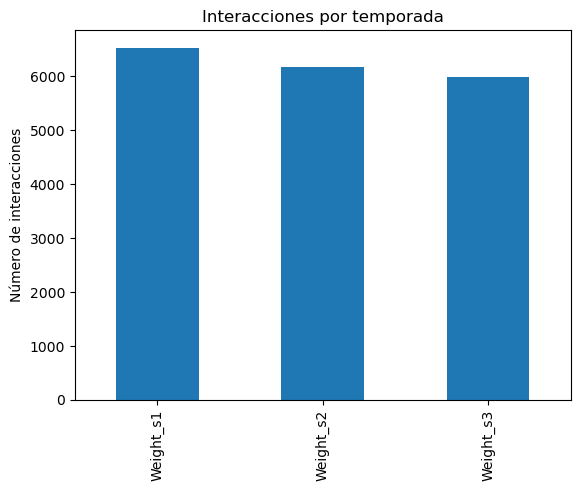

In [10]:
season_totals.plot(kind="bar")
plt.title("Interacciones por temporada")
plt.ylabel("Número de interacciones")
plt.show()

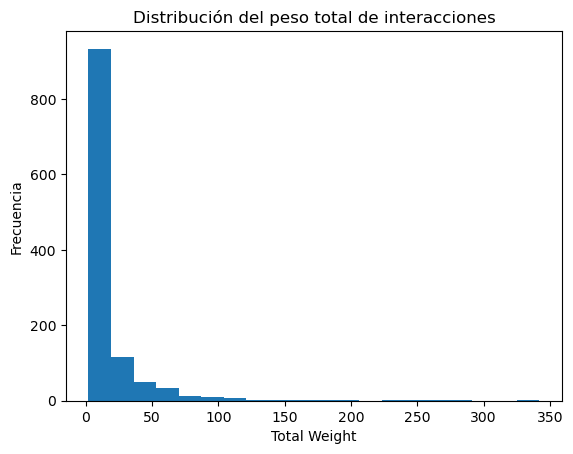

In [11]:
plt.hist(edges["Total_Weight"], bins=20)
plt.title("Distribución del peso total de interacciones")
plt.xlabel("Total Weight")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
G = nx.from_pandas_edgelist(
    edges,
    source="Source",
    target="Target",
    edge_attr="Total_Weight"
)



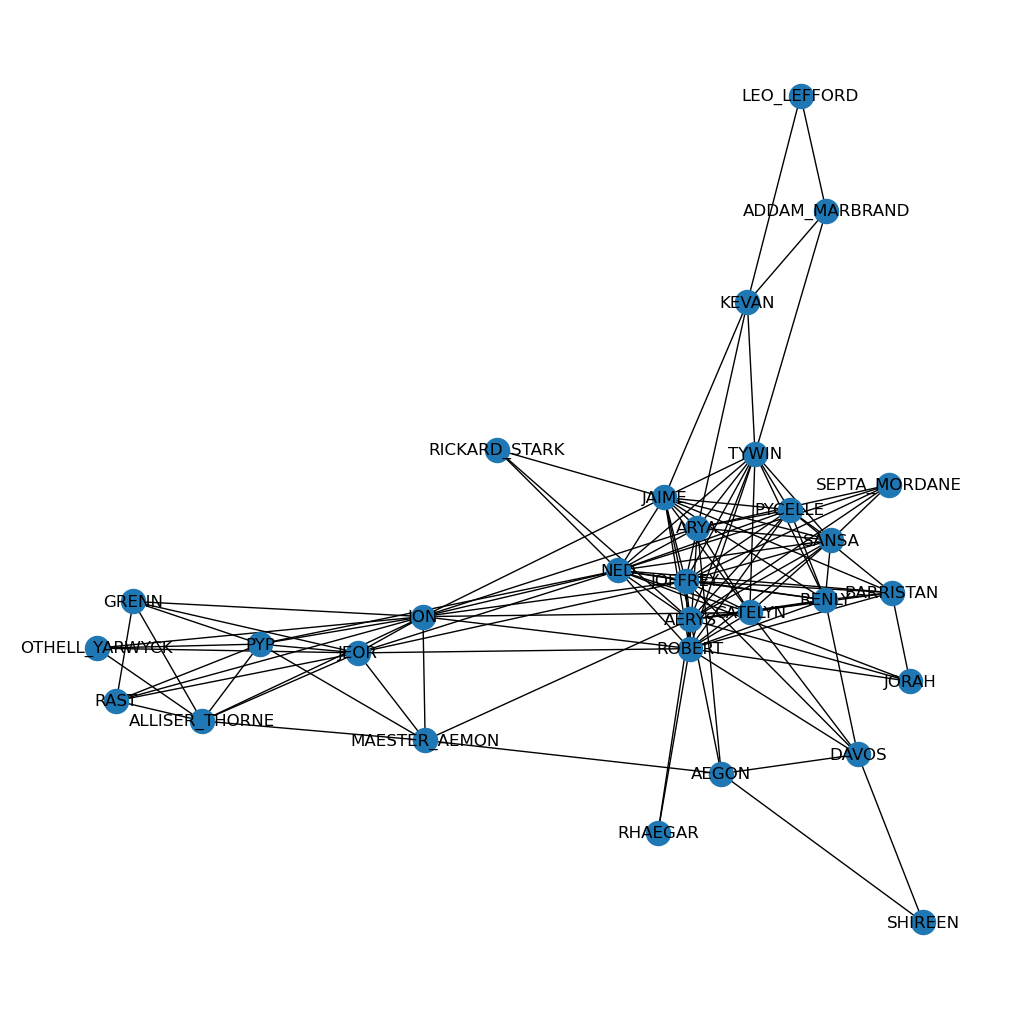

In [18]:
sub_nodes = list(G.nodes())[:30]

subgraph = G.subgraph(sub_nodes)

plt.figure(figsize=(10,10))

pos = nx.spring_layout(subgraph)

nx.draw(subgraph, pos, with_labels=True)

plt.show()

In [13]:
print("Número de nodos:", G.number_of_nodes())
print("Número de aristas:", G.number_of_edges())

Número de nodos: 237
Número de aristas: 1182


In [14]:
degree = dict(G.degree())

top_characters = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]

print(top_characters)

[('TYRION', 64), ('NED', 62), ('CATELYN', 56), ('ROBB', 54), ('JOFFREY', 49), ('ARYA', 47), ('CERSEI', 47), ('ROBERT', 45), ('TYWIN', 42), ('JON', 42)]
